# Rule-Based AML Alert Baseline

Covers **Objective 3**: *"Build a rule-based baseline reflecting industry AML alert logic."*



## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

# Real results from 02_rule_baseline_full_v2.py, run against the full HI-Small dataset,
# restricted to the stable window (1-10 September).
N_ROWS = 5_077_237
N_LAUNDERING = 4_522

THRESHOLDS = {
    "high_value_threshold": 10_000,
    "structuring_band": [9_000, 10_000],
    "velocity_min_txns_per_24h": 10,
    "high_risk_formats": ["ACH"],
}
for k, v in THRESHOLDS.items():
    print(f"{k}: {v}")


high_value_threshold: 10000
structuring_band: [9000, 10000]
velocity_min_txns_per_24h: 10
high_risk_formats: ['ACH']


In [2]:
# ATTEMPT 1 -- percentile-based calibration, run on the full (untrimmed) dataset
attempt_1_thresholds = {
    "high_value_threshold": 13_524_530.71,   # 99th percentile of Amount Paid
    "structuring_band": [12_172_077.64, 13_524_530.71],
    "velocity_threshold_txns_per_24h": 19_551.6,  # also percentile-calibrated
}
attempt_1_results = {
    "n_alerts": 730_979, "alert_rate_pct": 14.394,
    "precision": 0.000332, "recall": 0.046938, "f1": 0.00066,
    "alerts_per_true_catch": 3_008.1,
}

print("Attempt 1 -- calibrated thresholds:")
for k, v in attempt_1_thresholds.items():
    print(f"  {k}: {v:,}" if isinstance(v, (int, float)) else f"  {k}: {v}")
print("\nAttempt 1 -- results:")
for k, v in attempt_1_results.items():
    print(f"  {k}: {v}")


Attempt 1 -- calibrated thresholds:
  high_value_threshold: 13,524,530.71
  structuring_band: [12172077.64, 13524530.71]
  velocity_threshold_txns_per_24h: 19,551.6

Attempt 1 -- results:
  n_alerts: 730979
  alert_rate_pct: 14.394
  precision: 0.000332
  recall: 0.046938
  f1: 0.00066
  alerts_per_true_catch: 3008.1


## 2. Rule firing frequency

In [3]:
rule_fire_counts = {
    "high_value": 1_369_964,
    "structuring": 51_149,
    "high_velocity": 1_231_906,
    "round_amount": 68,
    "high_risk_format": 599_689,
}
rule_pct = {k: round(v / N_ROWS * 100, 3) for k, v in rule_fire_counts.items()}

summary_df = pd.DataFrame({'count': rule_fire_counts, 'pct_of_transactions': rule_pct})
summary_df


                    count  pct_of_transactions
high_value        1369964               26.982
structuring         51149                1.007
high_velocity     1231906               24.263
round_amount           68                0.001
high_risk_format   599689               11.811

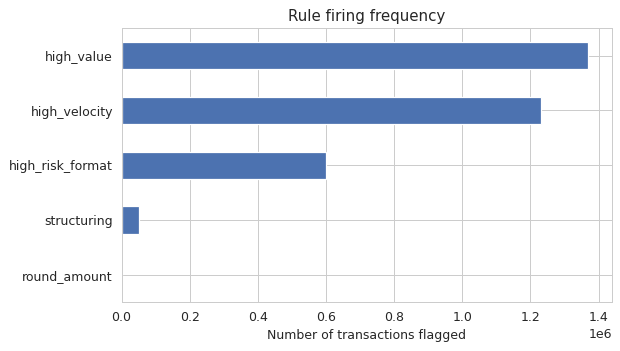

In [4]:
fig, ax = plt.subplots(figsize=(7,4))
pd.Series(rule_fire_counts).sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Number of transactions flagged')
ax.set_title('Rule firing frequency')
plt.tight_layout()
plt.show()


## 3. Combined alert volume

In [5]:
n_alerts = 2_607_758
alert_rate_pct = 51.362

print(f"Total alerts raised: {n_alerts:,} out of {N_ROWS:,} transactions ({alert_rate_pct:.2f}%)")
print(f"Roughly 1 in {int(N_ROWS/n_alerts)} transactions gets flagged for review.")


Total alerts raised: 2,607,758 out of 5,077,237 transactions (51.36%)
Roughly 1 in 1 transactions gets flagged for review.


Over half of all transactions get flagged. This is a stark, quantified illustration of the
problem the project's literature review cites naive OR combination of independent rules is
exactly how real AML systems arrive at 90-95% false-positive rates.

## 4. Evaluation against ground truth

In [6]:
cm = {"tn": 2_469_059, "fp": 2_603_656, "fn": 420, "tp": 4_102}
precision = 0.001573
recall = 0.907121
f1 = 0.003141

print("Confusion matrix:")
print(f"                    Predicted: No Alert   Predicted: Alert")
print(f"Actual: Legit           {cm['tn']:>10,}         {cm['fp']:>10,}")
print(f"Actual: Laundering      {cm['fn']:>10,}         {cm['tp']:>10,}")
print(f"\nPrecision: {precision:.6f}  ({precision*100:.4f}% of alerts are genuine laundering)")
print(f"Recall:    {recall:.6f}  ({recall*100:.2f}% of laundering caught)")
print(f"F1 score:  {f1:.6f}")


Confusion matrix:
                    Predicted: No Alert   Predicted: Alert
Actual: Legit            2,469,059          2,603,656
Actual: Laundering             420              4,102

Precision: 0.001573  (0.1573% of alerts are genuine laundering)
Recall:    0.907121  (90.71% of laundering caught)
F1 score:  0.003141


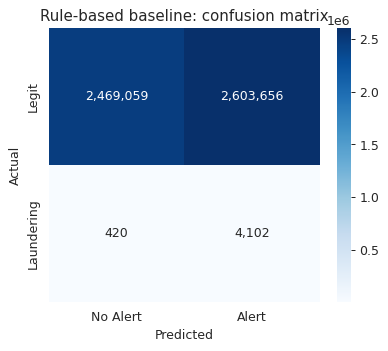

In [7]:
fig, ax = plt.subplots(figsize=(4.5,4))
cm_array = np.array([[cm['tn'], cm['fp']], [cm['fn'], cm['tp']]])
sns.heatmap(cm_array, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['No Alert', 'Alert'], yticklabels=['Legit', 'Laundering'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Rule-based baseline: confusion matrix')
plt.tight_layout()
plt.show()


## 5. Analyst workload framing

In [8]:
alerts_per_true_catch = 635.7
print(f"Alerts raised per genuine laundering case caught: {alerts_per_true_catch:.1f}")
print(f"i.e. an analyst reviews ~{alerts_per_true_catch:.0f} alerts to find 1 real laundering case.")
print()
print("This is the number the ML model needs to beat: for the SAME ~90.7% recall,")
print("can a cost-sensitive classifier require meaningfully fewer than 2.6M alerts?")


Alerts raised per genuine laundering case caught: 635.7
i.e. an analyst reviews ~636 alerts to find 1 real laundering case.

This is the number the ML model needs to beat: for the SAME ~90.7% recall,
can a cost-sensitive classifier require meaningfully fewer than 2.6M alerts?


## 6. Which rules actually matter?

In [9]:
per_rule_breakdown = {
    "high_value":       {"n_fired": 1_369_964, "n_laundering_caught": 2_004, "hit_rate_pct": 0.1463},
    "structuring":      {"n_fired": 51_149,    "n_laundering_caught": 123,   "hit_rate_pct": 0.2405},
    "high_velocity":    {"n_fired": 1_231_906, "n_laundering_caught": 945,   "hit_rate_pct": 0.0767},
    "round_amount":     {"n_fired": 68,        "n_laundering_caught": 0,     "hit_rate_pct": 0.0},
    "high_risk_format": {"n_fired": 599_689,   "n_laundering_caught": 3_828, "hit_rate_pct": 0.6383},
}
pd.DataFrame(per_rule_breakdown).T


                    n_fired  n_laundering_caught  hit_rate_pct
high_value        1369964.0               2004.0        0.1463
structuring         51149.0                123.0        0.2405
high_velocity     1231906.0                945.0        0.0767
round_amount           68.0                  0.0        0.0000
high_risk_format   599689.0               3828.0        0.6383

**`round_amount` contributes nothing** 

**`high_risk_format` (ACH) is doing most of the real work** 

In [10]:
ach_only_alerts, ach_only_catches = 599_689, 3_828
ach_only_precision = ach_only_catches / ach_only_alerts * 100
ach_only_recall = ach_only_catches / N_LAUNDERING * 100

combined_precision = precision * 100
combined_recall = recall * 100

comparison = pd.DataFrame({
    'ACH rule alone': [ach_only_alerts, ach_only_catches, f"{ach_only_recall:.2f}%", f"{ach_only_precision:.2f}%"],
    'All 5 rules combined': [n_alerts, cm['tp'], f"{combined_recall:.2f}%", f"{precision*100:.4f}%"],
}, index=['Alerts', 'Caught', 'Recall', 'Precision'])
comparison


          ACH rule alone All 5 rules combined
Alerts            599689              2607758
Caught              3828                 4102
Recall            84.65%               90.71%
Precision          0.64%              0.1573%

## 7. Final baseline numbers — locked in



In [11]:
final_baseline = {
    "n_rows": N_ROWS,
    "n_laundering": N_LAUNDERING,
    "n_alerts": n_alerts,
    "alert_rate_pct": alert_rate_pct,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "alerts_per_true_catch": alerts_per_true_catch,
}
for k, v in final_baseline.items():
    print(f"{k}: {v}")


n_rows: 5077237
n_laundering: 4522
n_alerts: 2607758
alert_rate_pct: 51.362
precision: 0.001573
recall: 0.907121
f1: 0.003141
alerts_per_true_catch: 635.7


## Summary & next steps

- Rule-based baseline finalized on the stable window: **51.4% alert rate, 90.7% recall, 0.16%
  precision, ~636 alerts per true catch.**
- Key insight carried forward: ACH (not Bitcoin/Cash) is the dominant single rule signal in this
  dataset informs feature engineering for the ML model too.
- Key limitation carried forward: naive rule-stacking is inefficient (4x precision cost for +6pp
  recall) this baseline is intentionally realistic of real world AML alert fatigue, not
  artificially optimized.

